# Population loss dynamics

In [2]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from POPloss import evo_loss, token_freq, u_jn, u_j_greedy, u_j_flip_mp

## $L(t)$ and $q(t)$ dynamics at fixed $\beta$ and different vocabulary sizes $d$

## Random u

/tmp/ipykernel_194002/1686488108.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Oranges')


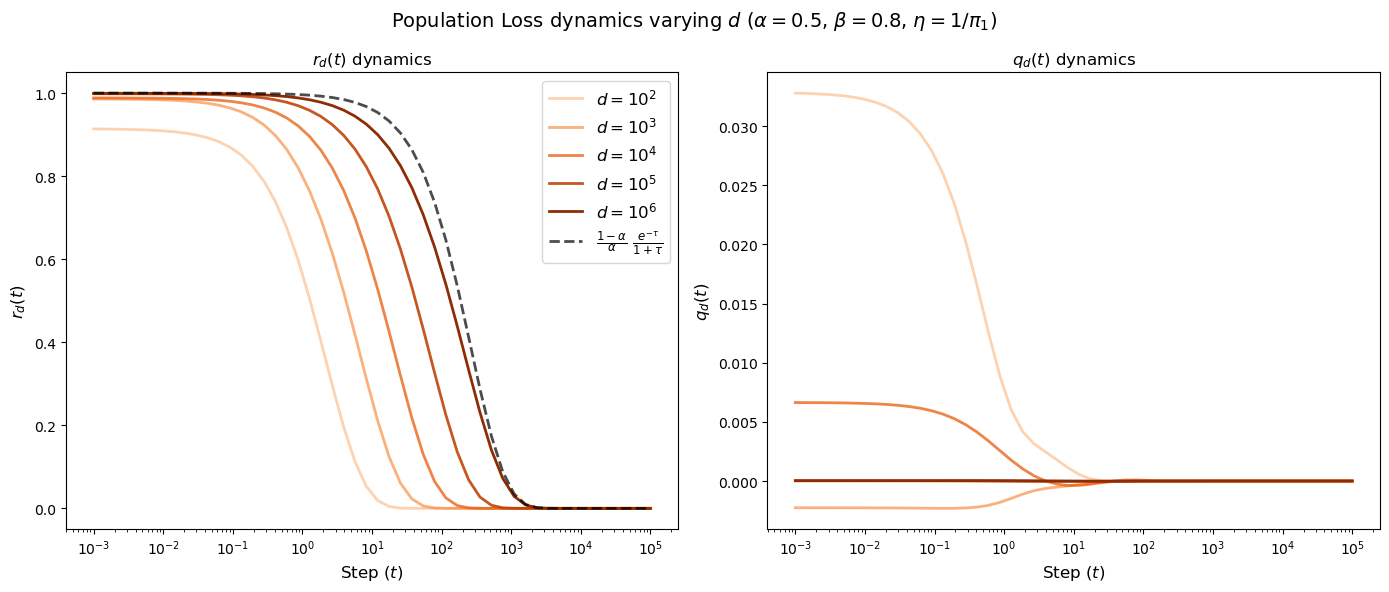

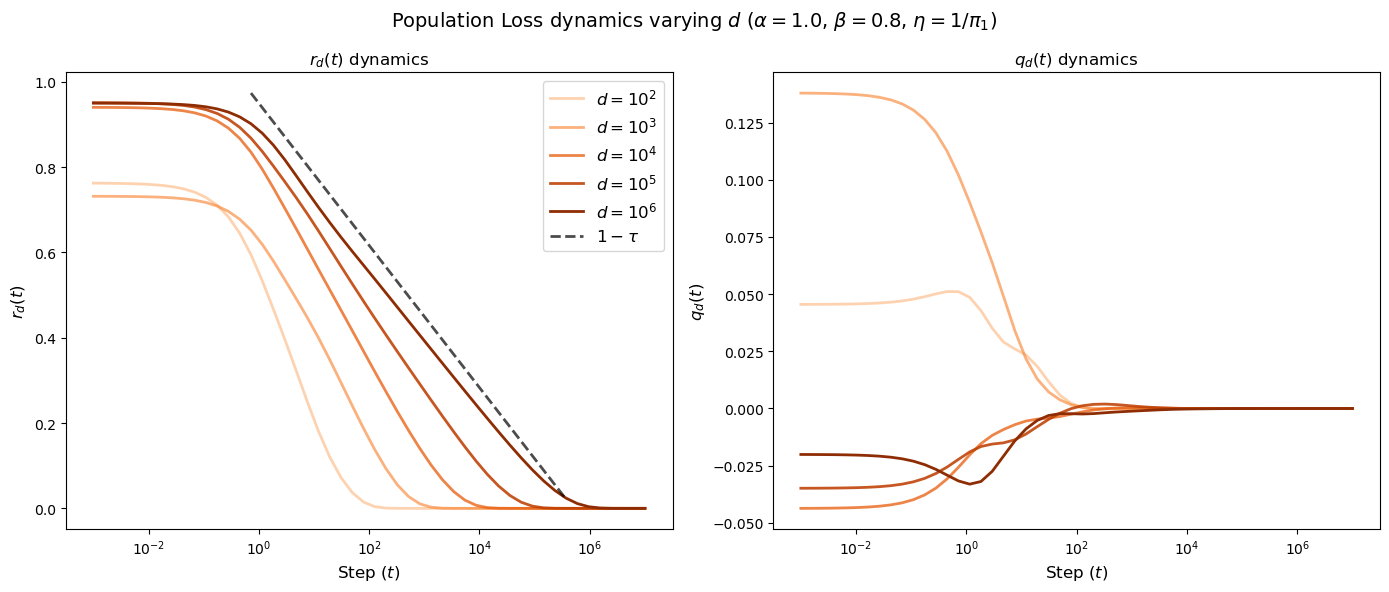

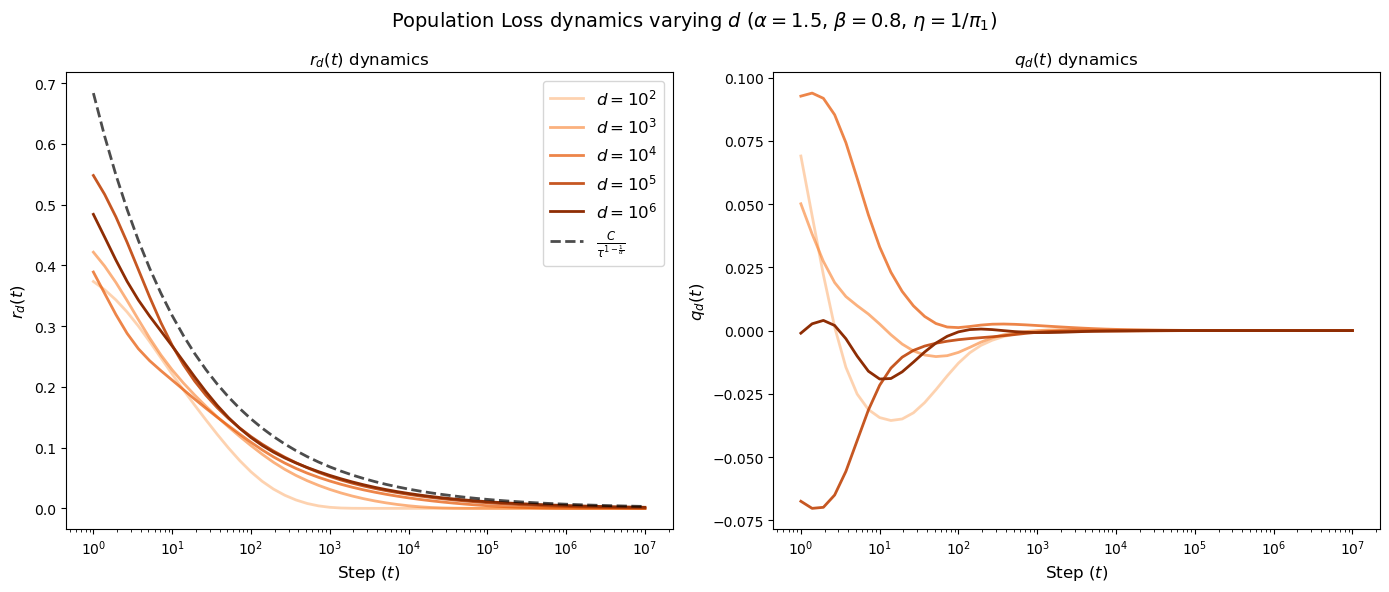

In [9]:
beta = 0.8

ds = [int(1e2), int(1e3), int(1e4), int(1e5), int(1e6)]
alphas = [0.5, 1.0, 1.5]
num_ds = len(ds)

cmap = cm.get_cmap('Oranges')
color_intensities = np.linspace(0.4, 0.95, num_ds)
trasp = np.linspace(0.50, 1.0, num_ds)

for alpha in alphas:
    if alpha < 1.0:
        t_start, t_stop = 1e-3 , 1e5
    if alpha == 1.0:
        t_start, t_stop = 1e-3 , 1e7
    if alpha > 1.0:
        t_start, t_stop = 1 , 1e7

    fig, (ax_L, ax_q) = plt.subplots(1, 2, figsize=(14, 6))

    for i, d in enumerate(ds):

        pi = token_freq(d, alpha)
        ####greedy####
        #u_j = u_j_greedy(d, pi)
        ####random###
        u_j = u_jn(d)
        eta = 1/pi[0]
        #eta = 0.1

        t_steps, dynamics, dynamics_b, dynamics_q, _, refline = evo_loss(d, alpha, pi, u_j, beta, eta, t_start, t_stop)

        exponent = int(round(np.log10(d)))

        ax_L.plot(t_steps, dynamics, linestyle='-', color=cmap(color_intensities[i]),
                  alpha=trasp[i], linewidth=2.0, label=fr'$d = 10^{{{exponent}}}$')

        ax_q.plot(t_steps, dynamics_q, linestyle='-', color=cmap(color_intensities[i]),
                  alpha=trasp[i], linewidth=2.0, label=fr'$d = 10^{{{exponent}}}$')

    if alpha < 1.0:
        ax_L.plot(t_steps, refline, linestyle='--', color='black',
                    alpha=0.7, linewidth=2.0, label=r'$ \frac{1-\alpha}{\alpha}$ $\frac{e^{-\tau}}{1+\tau}$')

    if alpha == 1.0:
        ref_arr = np.array(refline)
        
        # Define the value range (10^-1 to 10^5)
        mask = (t_steps >= 1/2) & (t_steps <= d/2)
        
        ax_L.plot(t_steps[mask], ref_arr[mask], linestyle='--', color='black',
                  alpha=0.7, linewidth=2.0, label=r'$ 1 - \tau$')

    if alpha > 1.0:
        ax_L.plot(t_steps, refline, linestyle='--', color='black',
                    alpha=0.7, linewidth=2.0, label=r'$ \frac{C}{\tau^{1-\frac{1}{\alpha}}}$')

    ax_L.set_title(r'$r_{d}(t)$ dynamics')
    ax_L.set_xlabel(r'Step ($t$)', fontsize=12)
    ax_L.set_ylabel(r'$r_d(t)$', fontsize=12)
    ax_L.set_xscale('log')
    #ax_L.set_yscale('log')
    ax_L.legend(fontsize=12)

    ax_q.set_title(r'$q_{d}(t)$ dynamics')
    ax_q.set_xlabel(r'Step ($t$)', fontsize=12)
    ax_q.set_ylabel(r'$q_d(t)$', fontsize=12)
    ax_q.set_xscale('log')
    #ax_q.set_yscale('log')
    #ax_q.legend(fontsize=12)
    fig.suptitle(fr'Population Loss dynamics varying $d$ ($\alpha={alpha}$, $\beta={beta}$, $\eta = 1/\pi_1$) ', fontsize=14)
    fig.tight_layout()
    fig.savefig(fr'/home/lucadriu/Desktop/uni/Tesi/Final/experiments/population/plots/loss_vs_d/loss_and_q_{alpha}_{beta}.png')
    plt.show()

## Greedy u

/tmp/ipykernel_194002/1981599039.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Oranges')


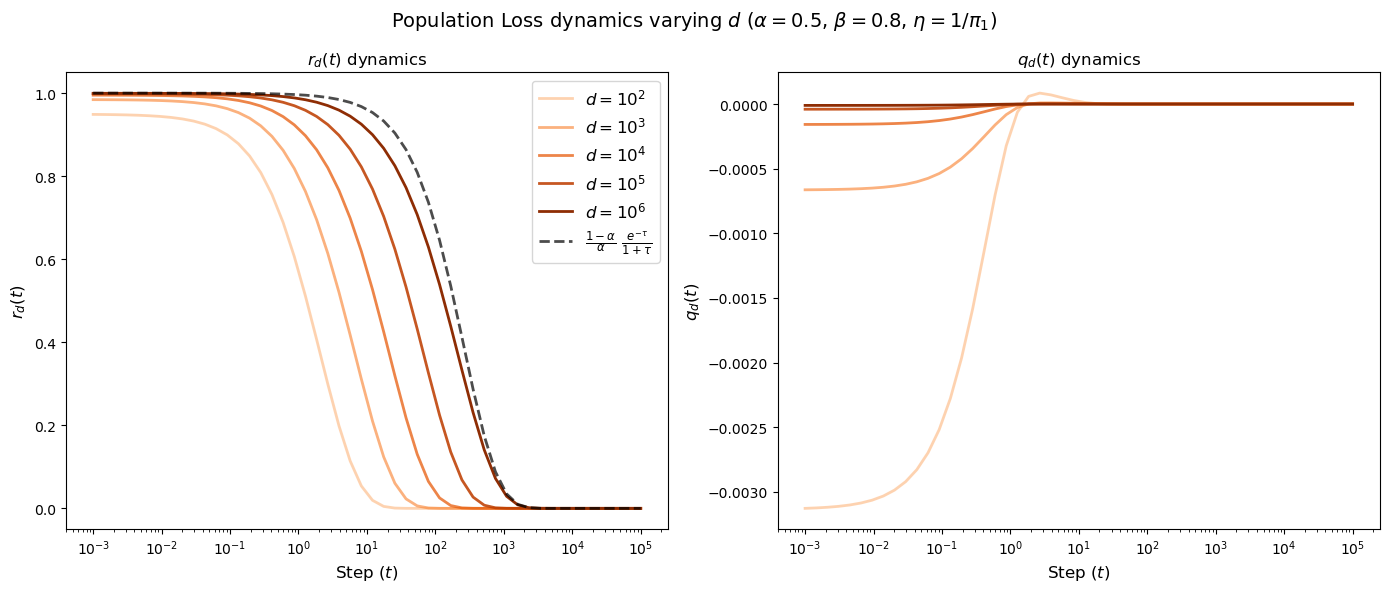

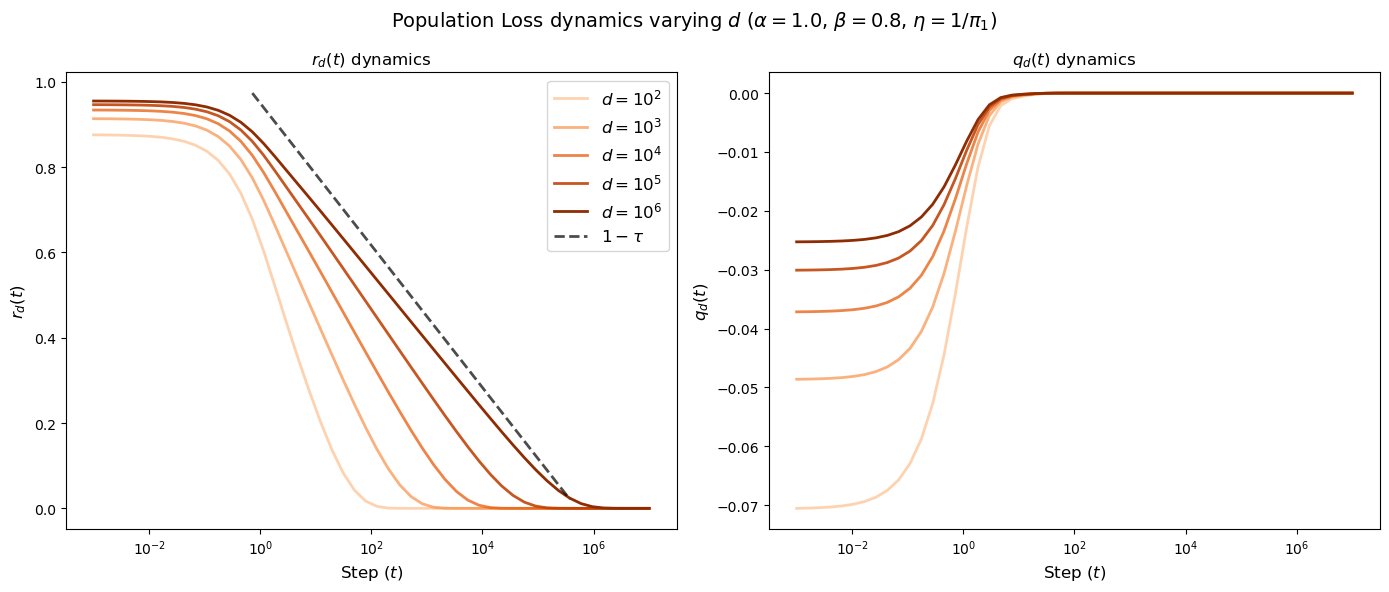

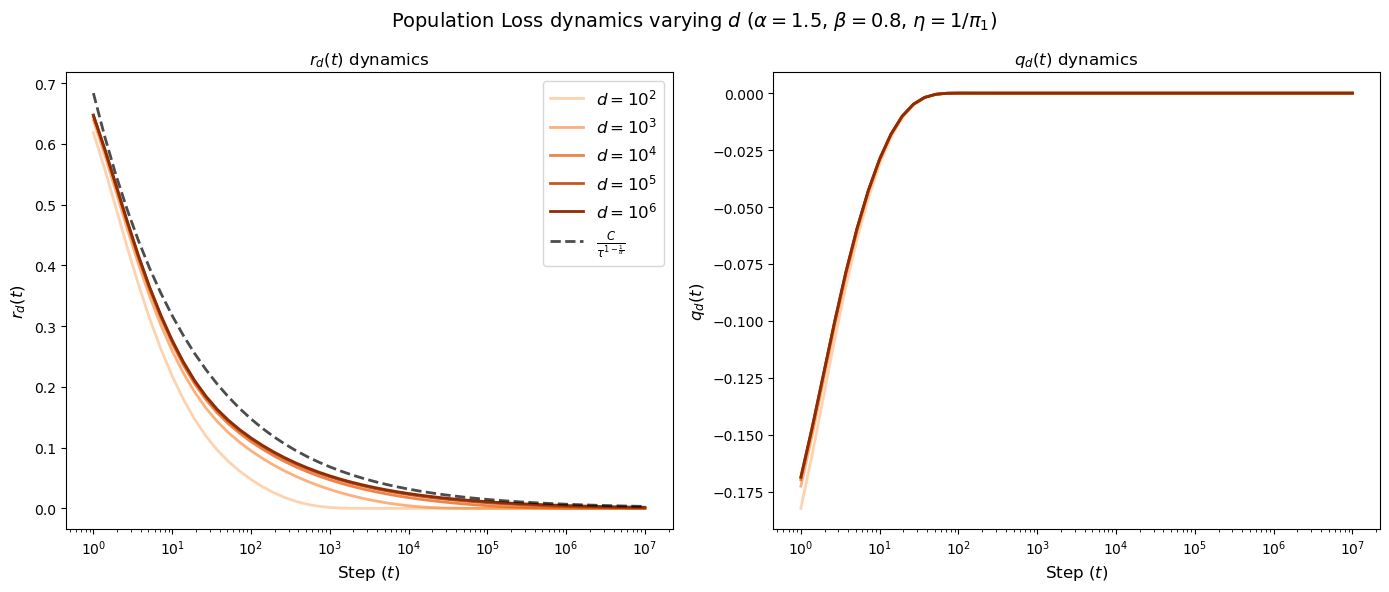

In [10]:
beta = 0.8

ds = [int(1e2), int(1e3), int(1e4), int(1e5), int(1e6)]
alphas = [0.5, 1.0, 1.5]
num_ds = len(ds)

cmap = cm.get_cmap('Oranges')
color_intensities = np.linspace(0.4, 0.95, num_ds)
trasp = np.linspace(0.50, 1.0, num_ds)

for alpha in alphas:
    if alpha < 1.0:
        t_start, t_stop = 1e-3 , 1e5
    if alpha == 1.0:
        t_start, t_stop = 1e-3 , 1e7
    if alpha > 1.0:
        t_start, t_stop = 1 , 1e7

    fig, (ax_L, ax_q) = plt.subplots(1, 2, figsize=(14, 6))

    for i, d in enumerate(ds):

        pi = token_freq(d, alpha)
        ####greedy####
        u_j = u_j_greedy(d, pi)
        ####random###
        #u_j = u_jn(d)
        eta = 1/pi[0]

        t_steps, dynamics, dynamics_b, dynamics_q, _, refline = evo_loss(d, alpha, pi, u_j, beta, eta, t_start, t_stop)

        exponent = int(round(np.log10(d)))

        ax_L.plot(t_steps, dynamics, linestyle='-', color=cmap(color_intensities[i]),
                  alpha=trasp[i], linewidth=2.0, label=fr'$d = 10^{{{exponent}}}$')

        ax_q.plot(t_steps, dynamics_q, linestyle='-', color=cmap(color_intensities[i]),
                  alpha=trasp[i], linewidth=2.0, label=fr'$d = 10^{{{exponent}}}$')

    if alpha < 1.0:
        ax_L.plot(t_steps, refline, linestyle='--', color='black',
                    alpha=0.7, linewidth=2.0, label=r'$ \frac{1-\alpha}{\alpha}$ $\frac{e^{-\tau}}{1+\tau}$')

    if alpha == 1.0:
        ref_arr = np.array(refline)
        
        # Define the value range (10^-1 to 10^5)
        mask = (t_steps >= 1/2) & (t_steps <= d/2)
        
        ax_L.plot(t_steps[mask], ref_arr[mask], linestyle='--', color='black',
                  alpha=0.7, linewidth=2.0, label=r'$ 1 - \tau$')

    if alpha > 1.0:
        ax_L.plot(t_steps, refline, linestyle='--', color='black',
                    alpha=0.7, linewidth=2.0, label=r'$ \frac{C}{\tau^{1-\frac{1}{\alpha}}}$')

    ax_L.set_title(r'$r_{d}(t)$ dynamics')
    ax_L.set_xlabel(r'Step ($t$)', fontsize=12)
    ax_L.set_ylabel(r'$r_d(t)$', fontsize=12)
    ax_L.set_xscale('log')
    #ax_L.set_yscale('log')
    ax_L.legend(fontsize=12)

    ax_q.set_title(r'$q_{d}(t)$ dynamics')
    ax_q.set_xlabel(r'Step ($t$)', fontsize=12)
    ax_q.set_ylabel(r'$q_d(t)$', fontsize=12)
    ax_q.set_xscale('log')
    #ax_q.set_yscale('log')
    #ax_q.legend(fontsize=12)
    fig.suptitle(fr'Population Loss dynamics varying $d$ ($\alpha={alpha}$, $\beta={beta}$, $\eta = 1/\pi_1$) ', fontsize=14)
    fig.tight_layout()
    fig.savefig(fr'/home/lucadriu/Desktop/uni/Tesi/Final/experiments/population/plots/loss_vs_d/loss_and_q_{alpha}_{beta}.png')
    plt.show()

## Recovering the Bach scaling law 

/tmp/ipykernel_213755/340978102.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Oranges')


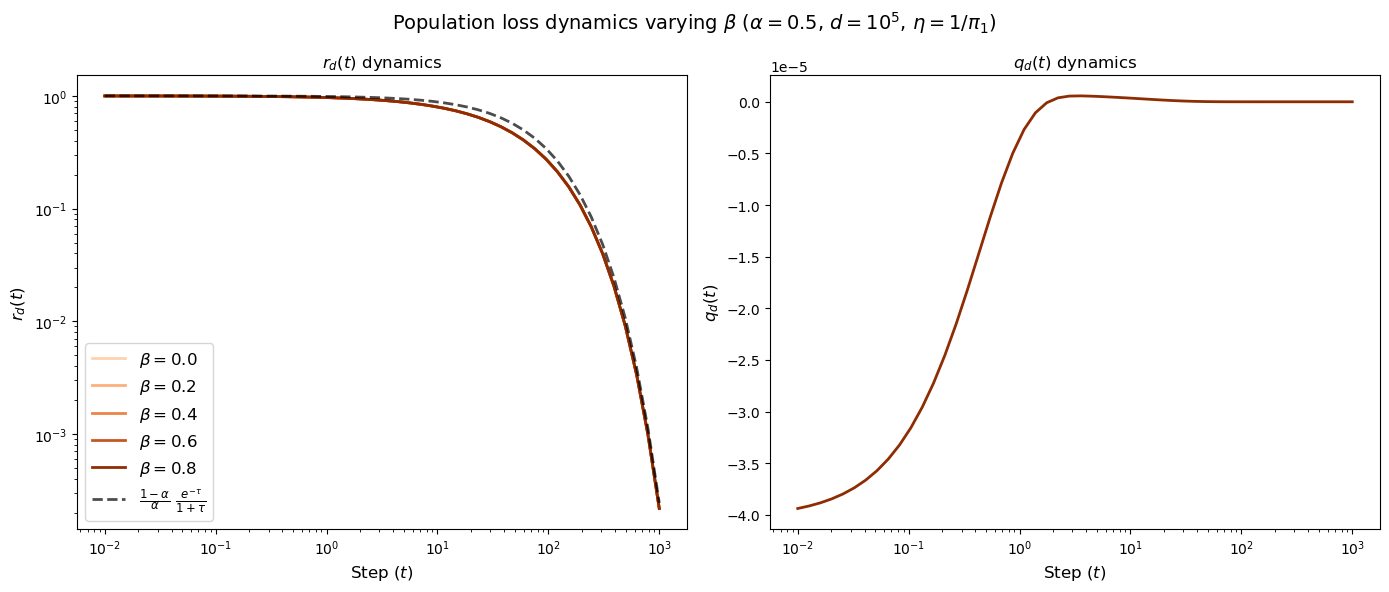

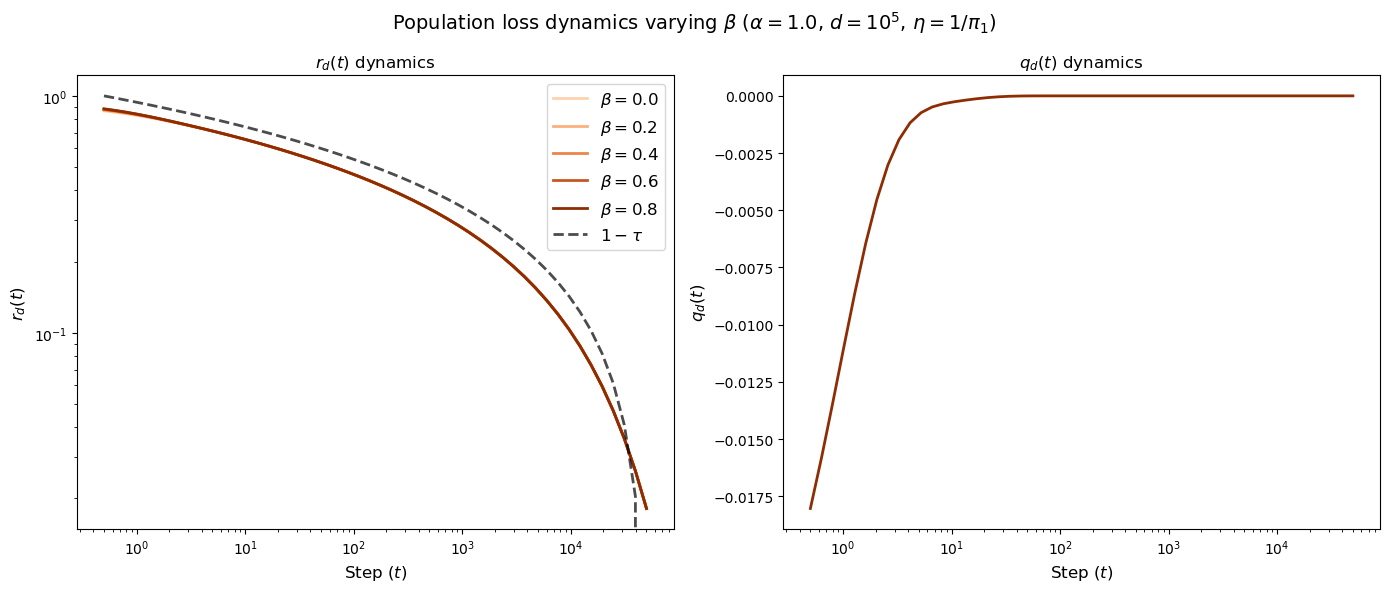

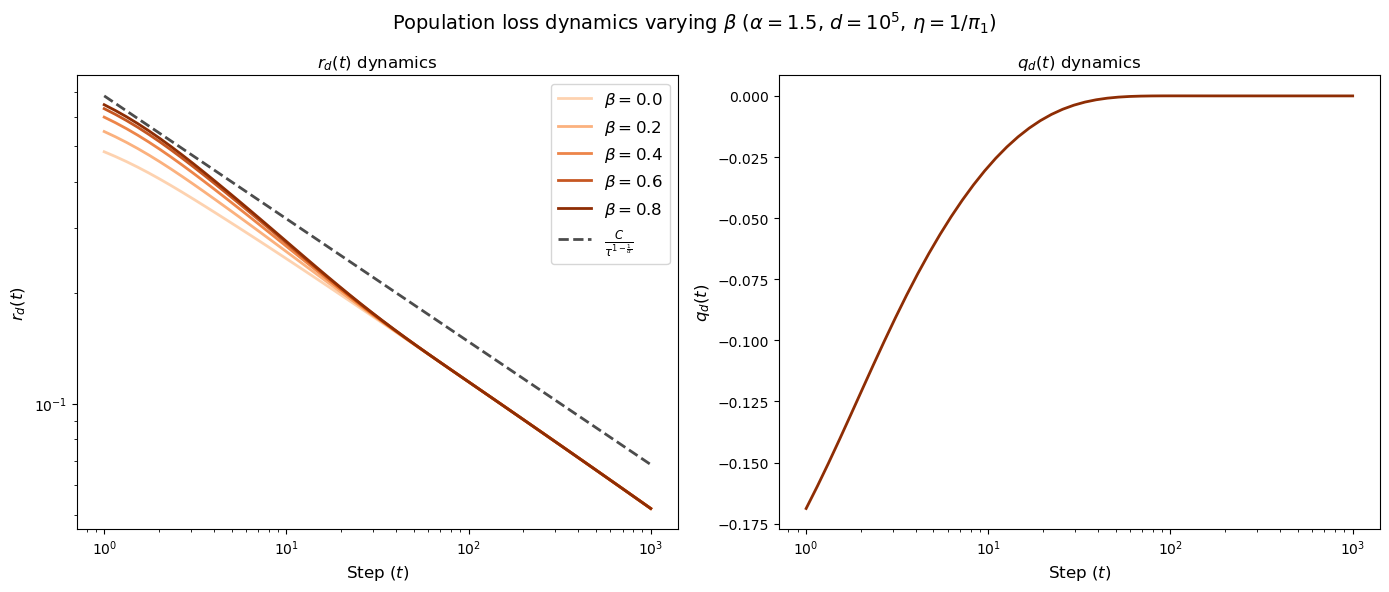

In [4]:
power=5
d = int(10**power)

betas = [0.00, 0.2, 0.40, 0.6, 0.8]
alphas = [0.5, 1.0, 1.5]
num_betas = len(betas)

cmap = cm.get_cmap('Oranges')
color_intensities = np.linspace(0.4, 0.95, num_betas)
trasp = np.linspace(0.50, 1.0, num_betas)

for alpha in alphas:
    if alpha < 1.0:
        t_start, t_stop = 1e-2 , 1e3
    if alpha == 1.0:
        t_start, t_stop = 0.5 , d/2
    if alpha > 1.0:
        t_start, t_stop = 1 , 1e3

    pi = token_freq(d, alpha)
    u_j = u_j_greedy(d, pi)
    #u_j = u_jn(d)
    eta = 1/pi[0]

    fig, (ax_L, ax_q) = plt.subplots(1, 2, figsize=(14, 6))

    for i, beta in enumerate(betas):

        t_steps, dynamics, _, dynamics_q, _, refline = evo_loss(d, alpha, pi, u_j, beta, eta, t_start, t_stop)
        ax_L.plot(t_steps, dynamics, linestyle='-', color=cmap(color_intensities[i]),
                  alpha=trasp[i], linewidth=2.0, label=f'$\\beta = {beta}$')

    ax_q.plot(t_steps, dynamics_q, linestyle='-', color=cmap(color_intensities[-1]),
              linewidth=2.0, label=r'$q(t)$ (greedy $u$)')

    if alpha < 1.0:
        ax_L.plot(t_steps, refline, linestyle='--', color='black',
                  alpha = 0.7, linewidth=2.0, label=r'$ \frac{1-\alpha}{\alpha}$ $\frac{e^{-\tau}}{1+\tau}$')
        #ax_L.set_title(fr'$\mathcal{{L}}(t)/\mathcal{{L}}(0)$, $t_d(\tau) = \frac{{1}}{{2}}\tau d^{{\alpha}}$')

    if alpha == 1.0:
        ref_arr = np.array(refline)
        
        # Define the value range (10^-1 to 10^5)
        mask = (t_steps >= 1/2) & (t_steps <= d/2)
        
        ax_L.plot(t_steps[mask], ref_arr[mask], linestyle='--', color='black',
                  alpha=0.7, linewidth=2.0, label=r'$ 1 - \tau$')

    if alpha > 1.0:
        ax_L.plot(t_steps, refline, linestyle='--', color='black',
                  alpha = 0.7, linewidth=2.0, label=r'$ \frac{C}{\tau^{1-\frac{1}{\alpha}}}$')
        #ax_L.set_title(fr'$\mathcal{{L}}(t)/\mathcal{{L}}(0)$, $t_d(\tau) = \tau$')

    ax_L.set_title(r'$r_{d}(t)$ dynamics')
    ax_L.set_xlabel(r'Step ($t$)', fontsize=12)
    ax_L.set_ylabel(r'$r_{d}(t)$', fontsize=12)
    ax_L.set_xscale('log')
    ax_L.set_yscale('log')
    ax_L.legend(fontsize=12)

    ax_q.set_title(r'$q_d(t)$ dynamics')
    ax_q.set_xlabel(r'Step ($t$)', fontsize=12)
    ax_q.set_ylabel(r'$q_d(t)$', fontsize=12)
    ax_q.set_xscale('log')
    #ax_q.set_yscale('log')
    #ax_q.legend(fontsize=12)
    fig.suptitle(fr'Population loss dynamics varying $\beta$ ($\alpha={alpha}$, $d=10^{power}$, $\eta = 1/\pi_1$) ', fontsize=14)
    fig.tight_layout()
    fig.savefig(fr'/home/lucadriu/Desktop/uni/Tesi/Final/experiments/population/plots/loss_vs_beta/loss_and_q_{alpha}_{d}.png')
    plt.show()

## $|q(t)|$ dynamics across multiple vocabulary sizes
A(t) governs the dynamics of the perturbation term. Analytically, $ A(t)/\pi_1 = \sum_k u_k k^{-\alpha} (1- k^{-\alpha})^{2t}$ does not depend from the voc size when $\eta = 1/\pi_1$(showed below). In this context the dependence from d is totally in $\pi_1$
The curves for $A(t)$ starts from $A(0) = -\pi_1$ (checked analytically).
We define an empirical threshold value for A(t), below which we can considered its dynamics as stopped

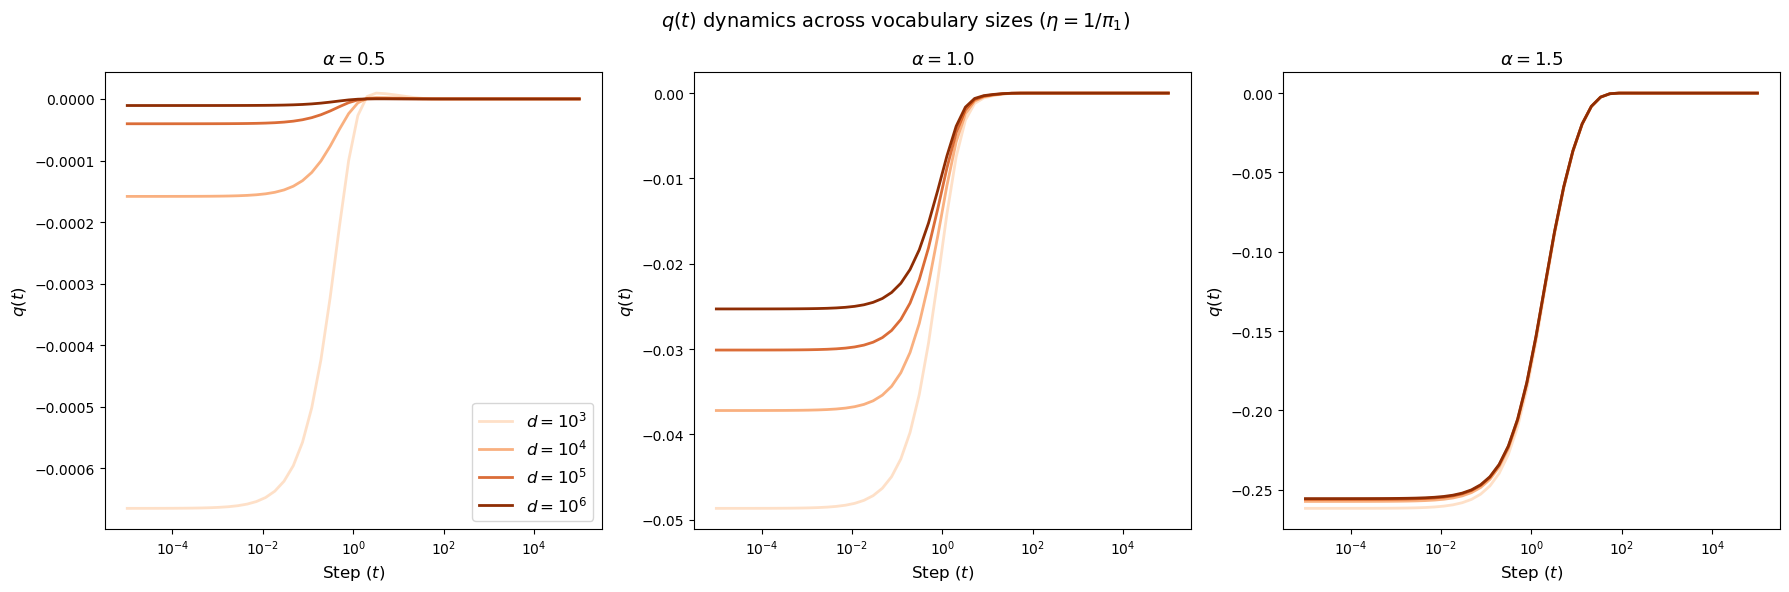

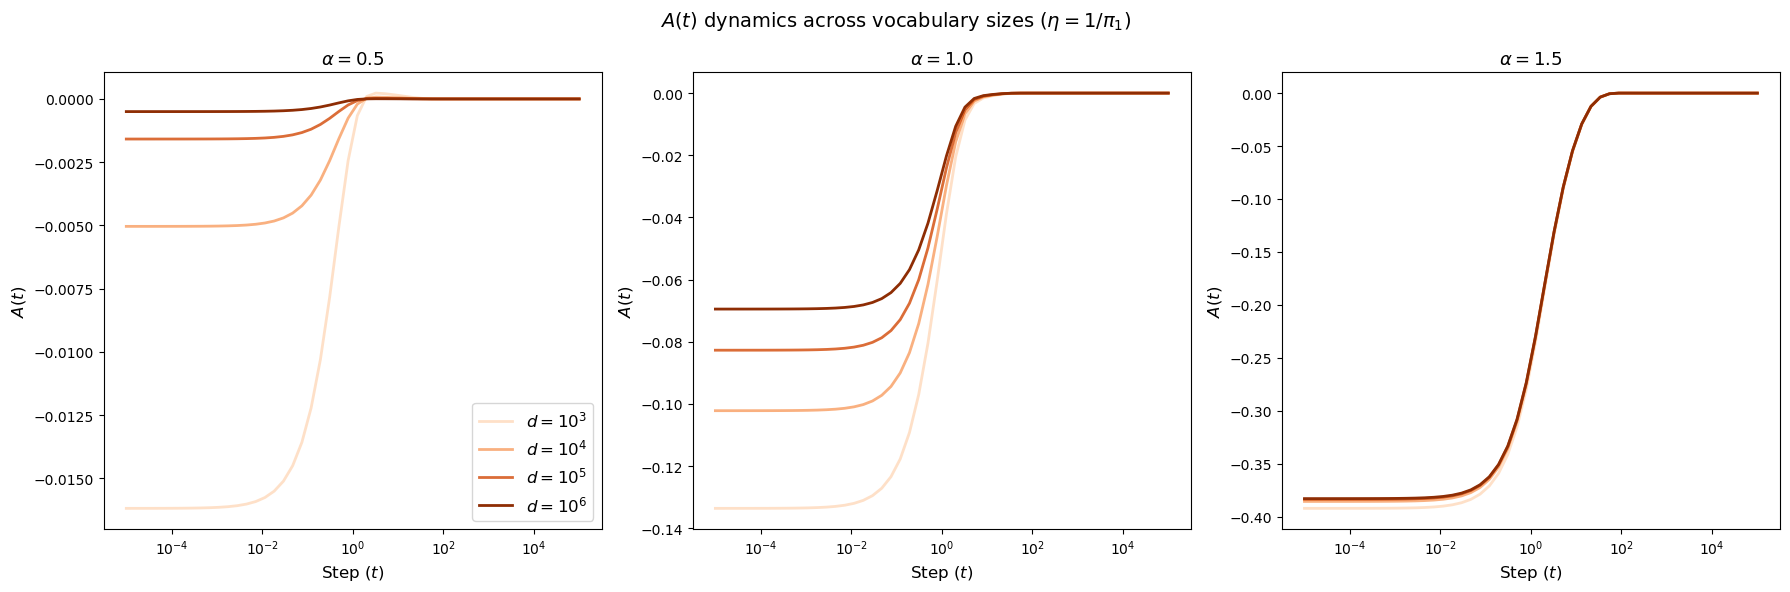

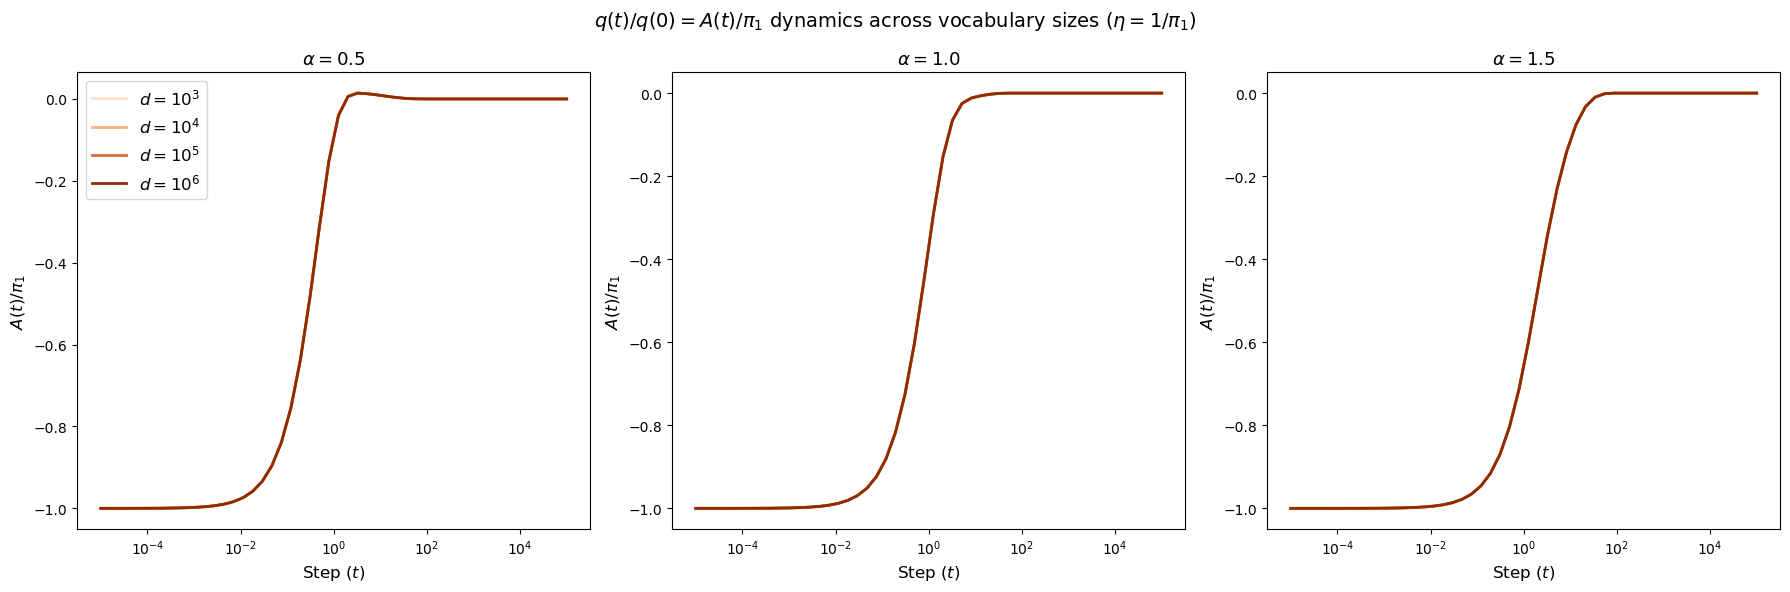

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from POPloss import evo_loss, token_freq, u_j_greedy

#------------------------------
t_start = 1e-5
t_stop  = 1e5
beta = 1
ds = [int(1e3), int(1e4), int(1e5), int(1e6)]
num_ds = len(ds)
alphas = [0.5, 1.0, 1.5]
num_alphas = len(alphas)

cmap = plt.get_cmap('Oranges')
color_intensities = np.linspace(0.4, 0.95, num_ds)   # light -> dark as d grows
trasp = np.linspace(0.35, 1.0, num_ds)               # transparent -> opaque as d grows

fig, axes = plt.subplots(1, num_alphas, figsize=(6 * num_alphas, 6), sharey=False)
fig2, axes2 = plt.subplots(1, num_alphas, figsize=(6 * num_alphas, 6), sharey=False)  # NEW
fig3, axes3 = plt.subplots(1, num_alphas, figsize=(6 * num_alphas, 6), sharey=False)  # NEW

for ax, ax2, ax3, alpha in zip(axes, axes2, axes3, alphas):  # NEW: added ax2

    for i, d in enumerate(ds):

        pi  = token_freq(d, alpha)
        u_j = u_j_greedy(d, pi)

        eta = 1/pi[0]
        t_steps, dynamics, dynamics_b, dynamics_q, dynamics_num2_sum1, refline = evo_loss(d, alpha, pi, u_j, beta, eta, t_start, t_stop)
        
        ax.plot(t_steps, dynamics_q, linestyle='-', color=cmap(color_intensities[i]),
                 alpha=trasp[i], linewidth=2.0, label=rf'$d = 10^{{{int(np.log10(d))}}}$')

        ax2.plot(t_steps, dynamics_num2_sum1, linestyle='-', color=cmap(color_intensities[i]),
                 alpha=trasp[i], linewidth=2.0, label=rf'$d = 10^{{{int(np.log10(d))}}}$')

        ax3.plot(t_steps, np.array(dynamics_num2_sum1) / pi[0], linestyle='-', color=cmap(color_intensities[i]),  # NEW
                 alpha=trasp[i], linewidth=2.0, label=rf'$d = 10^{{{int(np.log10(d))}}}$')  # NEW

    ax.set_title(rf'$\alpha = {alpha}$', fontsize=13)
    ax.set_xlabel(r'Step ($t$)', fontsize=12)
    ax.set_ylabel(r'$q(t)$', fontsize=12)
    ax.set_xscale('log')
    if alpha == 0.5:
        ax.legend(fontsize=12)

    ax2.set_title(rf'$\alpha = {alpha}$', fontsize=13)
    ax2.set_xlabel(r'Step ($t$)', fontsize=12)
    ax2.set_ylabel(r'$A(t)$', fontsize=12)
    ax2.set_xscale('log')
    if alpha == 0.5:
        ax2.legend(fontsize=12)

    ax3.set_title(rf'$\alpha = {alpha}$', fontsize=13)  # NEW
    ax3.set_xlabel(r'Step ($t$)', fontsize=12)  # NEW
    ax3.set_ylabel(r'$A(t)/\pi_1$', fontsize=12)  # NEW
    ax3.set_xscale('log')  # NEW
    if alpha == 0.5:  # NEW
        ax3.legend(fontsize=12)  # NEW

fig.suptitle(rf'$q(t)$ dynamics across vocabulary sizes ($\eta = 1/\pi_1$)', fontsize=14)
fig.tight_layout()
fig.savefig('/home/lucadriu/Desktop/uni/Tesi/Final/experiments/population/plots/single/q_dynam_vocab_all_alphas.png')

fig2.suptitle(rf'$A(t)$ dynamics across vocabulary sizes ($\eta = 1/\pi_1$)', fontsize=14)
fig2.tight_layout()
fig2.savefig('/home/lucadriu/Desktop/uni/Tesi/Final/experiments/population/plots/single/A_dynam_vocab_all_alphas.png')

fig3.suptitle(rf'$q(t)/q(0) = A(t)/\pi_1$ dynamics across vocabulary sizes ($\eta = 1/\pi_1$)', fontsize=14)  # NEW
fig3.tight_layout()  # NEW
fig3.savefig('/home/lucadriu/Desktop/uni/Tesi/Final/experiments/population/plots/single/A_pi_dynam_vocab_all_alphas.png')  # NEW

plt.show()

## 

/tmp/ipykernel_13523/549701480.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Oranges')


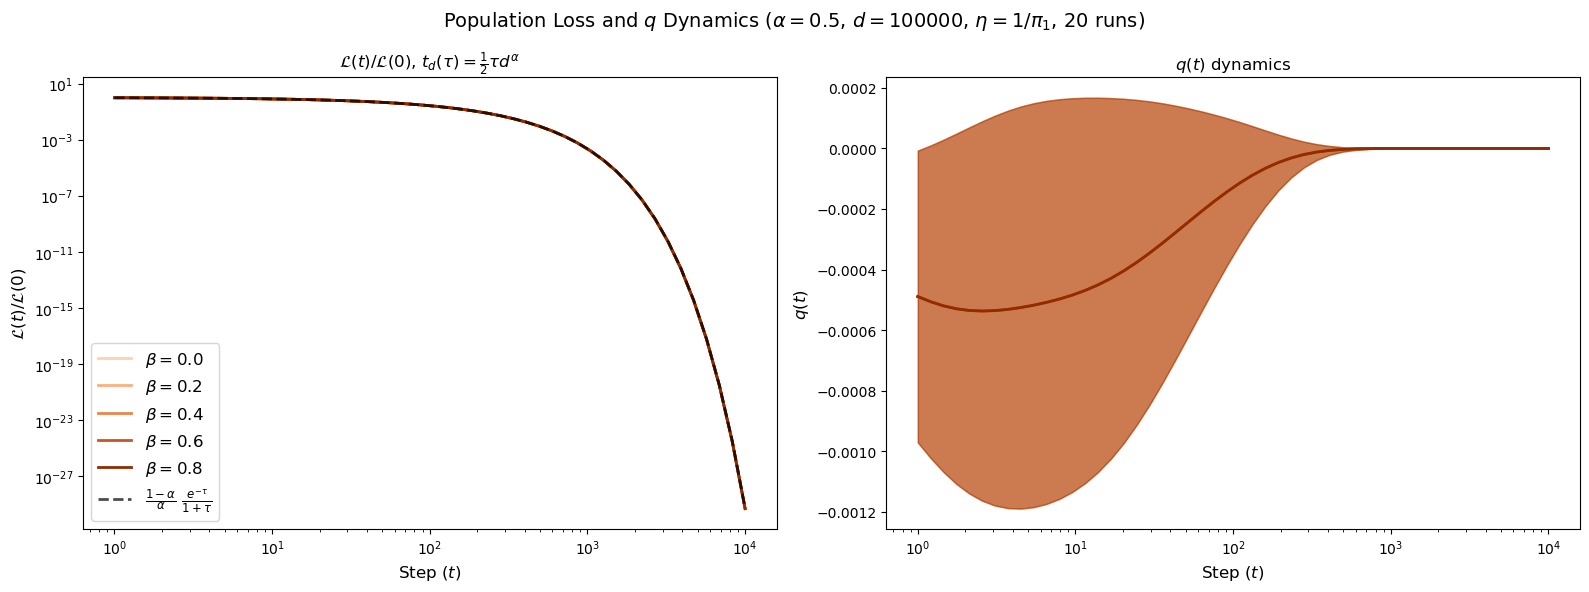

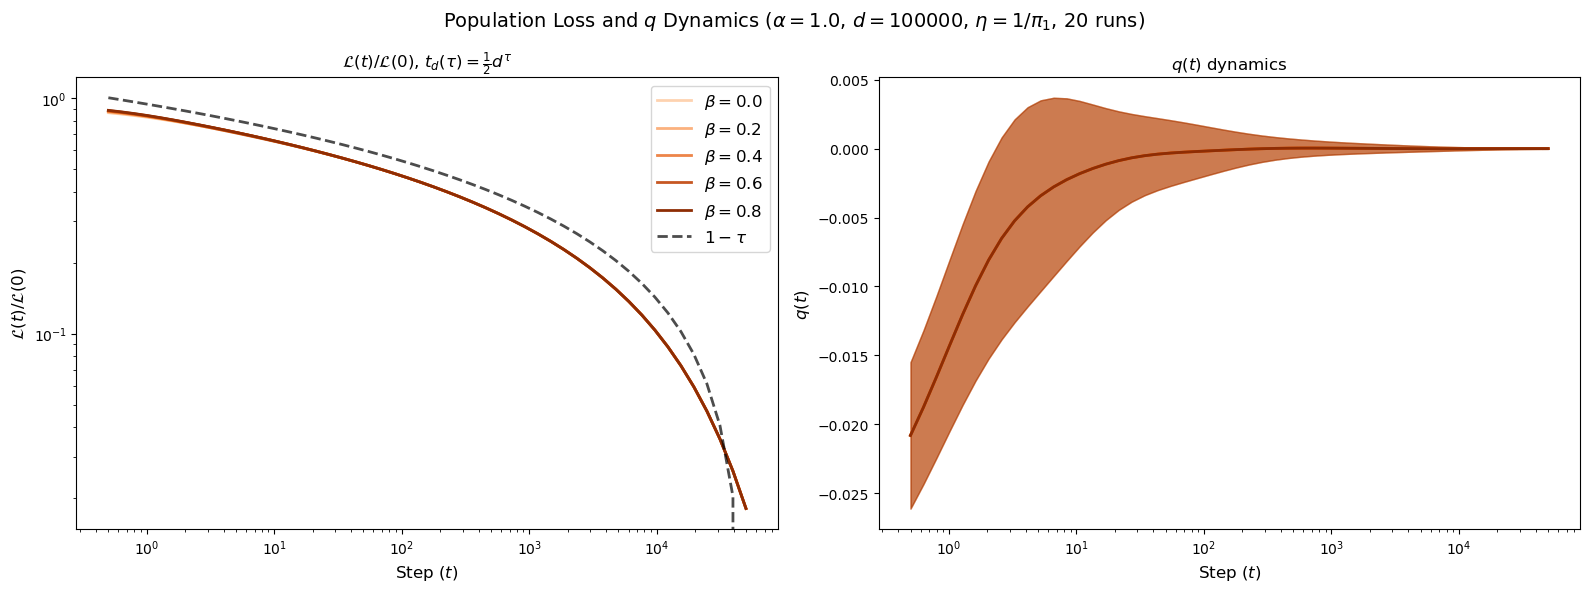

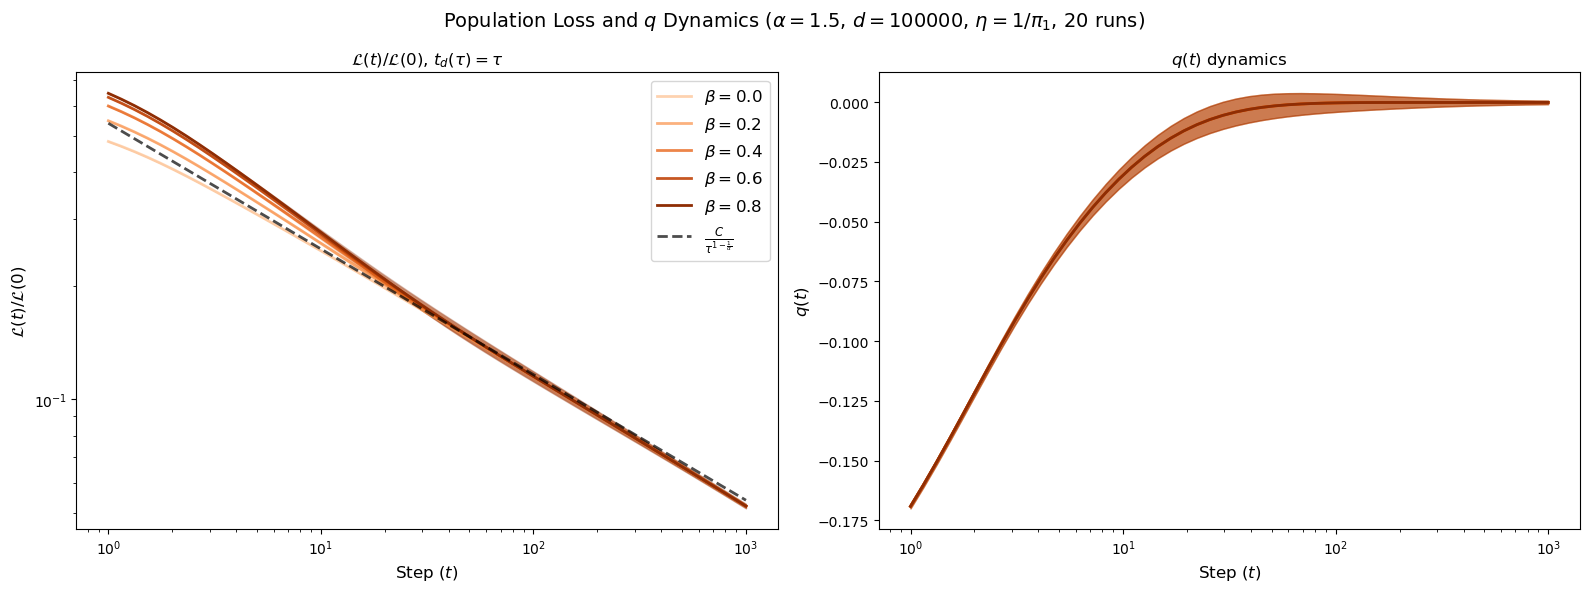

In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from POPloss import evo_loss_multi, token_freq

#------------------------------
d = int(1e5)
n_runs = 20
n_passes = 3

betas = [0.00, 0.2, 0.40, 0.6, 0.8]
alphas = [0.5, 1.0, 1.5]
num_betas = len(betas)

cmap = cm.get_cmap('Oranges')
color_intensities = np.linspace(0.4, 0.95, num_betas)
trasp = np.linspace(0.50, 1.0, num_betas)

for alpha in alphas:
    if alpha < 1.0:
        t_start, t_stop = 1 , 1e4
    if alpha == 1.0:
        t_start, t_stop = 0.5 , 5e4
    if alpha > 1.0:
        t_start, t_stop = 1 , 1e3

    pi = token_freq(d, alpha)
    eta = 1/pi[0]

    t_steps, mean_dyn, std_dyn, mean_dyn_q, std_dyn_q, refline = evo_loss_multi(d, alpha, pi, betas, eta,
                                                                               t_start, t_stop, n_runs, n_passes)

    fig, (ax_L, ax_q) = plt.subplots(1, 2, figsize=(16, 6))

    for i, beta in enumerate(betas):

        ax_L.plot(t_steps, mean_dyn[i], linestyle='-', color=cmap(color_intensities[i]),
                  alpha=trasp[i], linewidth=2.0, label=f'$\\beta = {beta}$')

        ax_L.fill_between(t_steps, mean_dyn[i] - std_dyn[i], mean_dyn[i] + std_dyn[i],
                          color=cmap(color_intensities[i]), alpha=trasp[i] * 0.3)

        ax_q.plot(t_steps, mean_dyn_q[i], linestyle='-', color=cmap(color_intensities[i]),
                  alpha=trasp[i], linewidth=2.0, label=f'$\\beta = {beta}$')

        ax_q.fill_between(t_steps, mean_dyn_q[i] - std_dyn_q[i], mean_dyn_q[i] + std_dyn_q[i],
                          color=cmap(color_intensities[i]), alpha=trasp[i] * 0.3)

    if alpha < 1.0:
        ax_L.plot(t_steps, refline, linestyle='--', color='black',
                  alpha = 0.7, linewidth=2.0, label=r'$ \frac{1-\alpha}{\alpha}$ $\frac{e^{-\tau}}{1+\tau}$')
        ax_L.set_title(fr'$\mathcal{{L}}(t)/\mathcal{{L}}(0)$, $t_d(\tau) = \frac{{1}}{{2}}\tau d^{{\alpha}}$')

    if alpha == 1.0:
        ax_L.plot(t_steps, refline, linestyle='--', color='black',
                  alpha = 0.7, linewidth=2.0, label=r'$ 1 - \tau$')
        ax_L.set_title(fr'$\mathcal{{L}}(t)/\mathcal{{L}}(0)$, $t_d(\tau) = \frac{{1}}{{2}}d^{{\tau}}$')

    if alpha > 1.0:
        ax_L.plot(t_steps, refline, linestyle='--', color='black',
                  alpha = 0.7, linewidth=2.0, label=r'$ \frac{C}{\tau^{1-\frac{1}{\alpha}}}$')
        ax_L.set_title(fr'$\mathcal{{L}}(t)/\mathcal{{L}}(0)$, $t_d(\tau) = \tau$')

    ax_L.set_xlabel(r'Step ($t$)', fontsize=12)
    ax_L.set_ylabel(r'$\mathcal{L}(t) / \mathcal{L}(0)$', fontsize=12)
    ax_L.set_xscale('log')
    ax_L.set_yscale('log')
    ax_L.legend(fontsize=12)

    ax_q.set_title(r'$q(t)$ dynamics')
    ax_q.set_xlabel(r'Step ($t$)', fontsize=12)
    ax_q.set_ylabel(r'$q(t)$', fontsize=12)
    ax_q.set_xscale('log')
    #ax_q.set_yscale('log')
    #ax_q.legend(fontsize=12)

    fig.suptitle(fr'Population Loss and $q$ Dynamics ($\alpha={alpha}$, $d={d}$, $\eta = 1/\pi_1$, {n_runs} runs) ', fontsize=14)
    fig.tight_layout()
    fig.savefig(fr'/home/lucadriu/Desktop/uni/Tesi/Final/experiments/population/plots/multi/loss_and_q_{alpha}_{d}.png')
    plt.show()